In [ ]:
!pip3 install transformers

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
import pandas as pd
import numpy as np
from transformers import AutoTokenizer,AutoModel
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader
from sklearn.metrics import *
device="cuda" if torch.cuda.is_available() else "cpu"
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_json('/content/Sarcasm.json',lines=True)
df.head()
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(np.array(df["headline"]),np.array(df["is_sarcastic"]),test_size=0.3)
x_val,x_test,y_val,y_test=train_test_split(x_test,y_test,test_size=0.5)
print('Training size',x_train.shape[0],"which is ",round(x_train.shape[0]/df.shape[0])*100,"%")

print('Training size',x_train.shape[0],"which is ",round(x_val.shape[0]/df.shape[0])*100,"%")

print('Training size',x_train.shape[0],"which is ",round(x_test.shape[0]/df.shape[0])*100,"%")

Training size 18695 which is  100 %
Training size 18695 which is  0 %
Training size 18695 which is  0 %


In [ ]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased")


In [ ]:
class dataset(Dataset):
  def __init__(self,x,y):
    self.x=[tokenizer(x,max_length=100,truncation=True,padding="max_length",return_tensors="pt").to(device) for x in x]
    self.y=torch.tensor(y).to(device)
  def __getitem__(self,idx):
    return self.x[idx],self.y[idx]
  def __len__(self):
    return len(self.y)
    self.tokenizer=tokenizer
training_data=dataset(x_train,y_train)
validation_data=dataset(x_val,y_val)
testing_data=dataset(x_test,y_test)

In [ ]:
BATCH_SIZE=32
EPOCHS=10
LR=1e-4

In [ ]:
train_dataloader=DataLoader(training_data,batch_size=BATCH_SIZE,shuffle=True)
validation_dataloader=DataLoader(validation_data,batch_size=BATCH_SIZE,shuffle=True)
testing_dataloader=DataLoader(testing_data,batch_size=BATCH_SIZE,shuffle=True)

In [ ]:
class Mymodel(nn.Module):
    def __init__(self, bert_model):
        super(Mymodel, self).__init__()
        self.bert = bert_model
        self.drop = nn.Dropout(0.3)
        self.linear1 = nn.Linear(768, 384)
        self.linear2 = nn.Linear(384, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, input_ids, attention_mask):
      output = self.bert(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)
      pooled_output = output[0][:, 0]  # CLS token
      x = self.linear1(pooled_output)
      x = self.drop(x)
      x = self.linear2(x)
      x = self.sigmoid(x)
      return x



In [ ]:
for param in bert_model.parameters():
  param.requires_grad=False
model=Mymodel(bert_model).to(device)
model

Mymodel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affin

In [ ]:
criterion=nn.BCELoss()
optimizer=Adam(model.parameters(),lr=LR)
total_loss_train_plot=[]
total_loss_validation_plot=[]
total_acc_train_plot=[]
total_acc_validation_plot=[]


In [ ]:
# Initialize metric tracking lists
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    # Training loop
    model.train()
    for index, data in enumerate(train_dataloader):
        inputs, labels = data
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.float().to(device)

        prediction = model(inputs["input_ids"].squeeze(1), inputs["attention_mask"]).squeeze(1)
        batch_loss = criterion(prediction, labels)

        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()

        total_loss_train += batch_loss.item()
        batch_acc = (prediction.round() == labels).sum().item() / len(labels)
        total_acc_train += batch_acc

    # Validation loop
    model.eval()
    with torch.no_grad():
        for index, data in enumerate(validation_dataloader):
            inputs, labels = data
            inputs = {k: v.to(device) for k, v in inputs.items()}
            labels = labels.float().to(device)

            prediction = model(inputs["input_ids"].squeeze(1), inputs["attention_mask"]).squeeze(1)
            batch_loss = criterion(prediction, labels)
            total_loss_val += batch_loss.item()
            acc = (prediction.round() == labels).sum().item() / len(labels)
            total_acc_val += acc

    # Append metrics
    total_loss_train_plot.append(round(total_loss_train / len(train_dataloader), 4))
    total_loss_validation_plot.append(round(total_loss_val / len(validation_dataloader), 4))
    total_acc_train_plot.append(round(total_acc_train / len(train_dataloader), 4))
    total_acc_validation_plot.append(round(total_acc_val / len(validation_dataloader), 4))

    # Print summary for this epoch
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {total_loss_train_plot[-1]} | Val Loss: {total_loss_validation_plot[-1]} | Train Acc: {total_acc_train_plot[-1]} | Val Acc: {total_acc_validation_plot[-1]}")


In [ ]:
with torch.no_grad():
  for index,data in enumerate(validation_dataloader):
    inputs,labels=data
    inputs.to(device)
    labels=labels.float().to(device)
    prediction=model(inputs["input_ids"].squeeze(1),inputs["attention_mask"]).squeeze(1)
    batch_loss=criterion(prediction,labels)
    total_loss_val+=batch_loss.item()
    acc=(prediction.round()==labels).sum().item()/len(labels)
    total_acc_val+=acc
total_loss_train_plot.append(round(total_loss_train/len(train_dataloader),4))
total_loss_validation_plot.append(round(total_loss_val/len(validation_dataloader),4))
total_acc_train_plot.append(round(total_acc_train/len(train_dataloader),4))
total_acc_validation_plot.append(round(total_acc_val/len(validation_dataloader),4))
print(f"""
Epoch No.{epoch+1} Train loss: {round(total_loss_train/1000,4)}""")



Epoch No.1 Train loss: 0.018


In [ ]:
## Testing

In [ ]:
with torch.no_grad():
  total_loss_test=0
  total_acc_test=0
  for index,data in enumerate(testing_dataloader):
    inputs,labels=data
    inputs.to(device)
    labels=labels.float().to(device)
    prediction=model(inputs["input_ids"].squeeze(1),inputs["attention_mask"]).squeeze(1)
    batch_loss=criterion(prediction,labels)
    total_loss_test+=batch_loss.item()
    acc=(prediction.round()==labels).sum().item()/len(labels)
    total_acc_test+=acc
print(f"Accuracy score is {round(total_acc_test/len(testing_dataloader),4)}")
print(f"Loss score is {round(total_loss_test/len(testing_dataloader),4)}")



Accuracy score is 0.4864
Loss score is 0.6973


In [ ]:
print("Train Loss:", total_loss_train_plot)
print("Val Loss:", total_loss_validation_plot)
print("Train Acc:", total_acc_train_plot)
print("Val Acc:", total_acc_validation_plot)

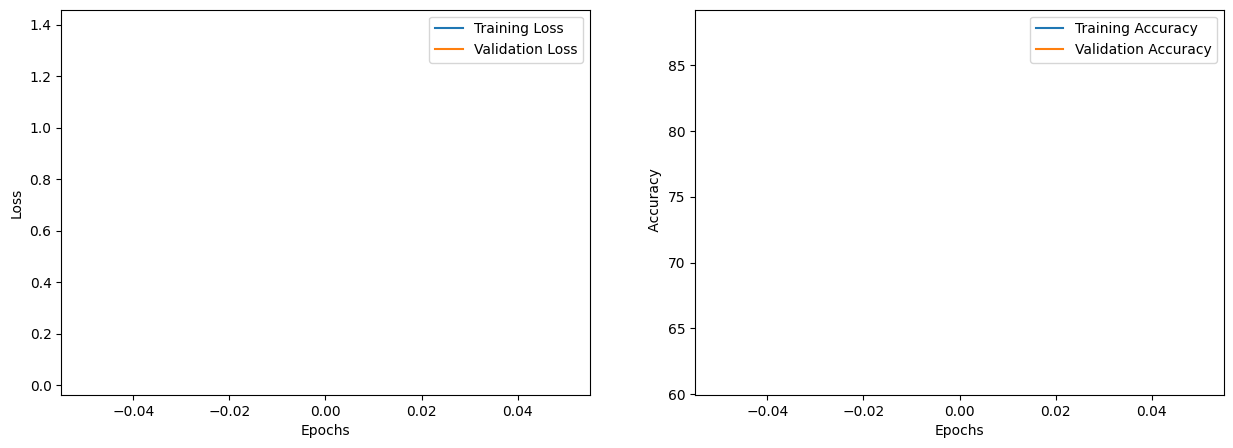

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(15,5))
axs[0].plot(total_loss_train_plot,label="Training Loss")
axs[0].plot(total_loss_validation_plot,label="Validation Loss")
axs[0].legend()
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[1].plot(total_loss_test,label="Training Accuracy")
axs[1].plot(total_acc_test,label="Validation Accuracy")
axs[1].legend()
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel(" Accuracy")
plt.show()